In [308]:
import os
import wave
from preprocessing import normalize_audio, whisper_tokinze, build_input

import numpy as np
import matplotlib.pyplot as plt

from transformers import WhisperProcessor, WhisperFeatureExtractor

import webrtcvad

processor = WhisperProcessor.from_pretrained(
	"./models/whisper-large-v3-turbo"
)

fe = WhisperFeatureExtractor.from_pretrained(
	"./models/whisper-large-v3-turbo"
)

vad = webrtcvad.Vad(2)


In [113]:
# /audio_20260513_174839.wav
AUDIO_DIR = 'saved_audio'
# TEST_AUDIO_PATH = list(map(lambda x: f"{AUDIO_DIR}/{x}", os.listdir(AUDIO_DIR)))
TEST_AUDIO_PATH = ['saved_audio/bnm-1-ys.wav']
print(TEST_AUDIO_PATH)
WINDOW_SIZE = int(16000 * 2)

PCM_DTYPE_BY_WIDTH = {
    1: np.int8,
    2: np.int16,
    4: np.int32,
}

def stream_audio_chunks(wav_data, chunk_size=4096):
    for i in range(0, len(wav_data), chunk_size):
        yield wav_data[i:i+chunk_size]

def read_audio(audio_path: str):
    with wave.open(audio_path, "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        channels = wav_file.getnchannels()
        sample_width = wav_file.getsampwidth()
        n_frames = wav_file.getnframes()

        print(f"Audio file info: sample_rate={sample_rate}, channels={channels}, sample_width={sample_width}, n_frames={n_frames}")
        wav_data = wav_file.readframes(n_frames)
        print(f"Read {len(wav_data)} bytes of audio data from {audio_path}")

        if sample_width not in PCM_DTYPE_BY_WIDTH:
            raise ValueError(f"Unsupported sample width: {sample_width}")

        # Convert raw PCM bytes to float32 in [-1, 1] for safe processing.
        pcm_dtype = PCM_DTYPE_BY_WIDTH[sample_width]
        raw_audio = np.frombuffer(wav_data, dtype=pcm_dtype)
        if channels > 1:
            raw_audio = raw_audio.reshape(-1, channels).mean(axis=1)
            channels = 1

        raw_audio = raw_audio[int(sample_rate * 60 * 8):int(sample_rate * 60 * 8.5)]

        info = np.iinfo(pcm_dtype)
        abs_max = float(max(info.max, abs(info.min)))
        audio = raw_audio.astype(np.float32) / abs_max

        if sample_rate != 16_000:
            print("Resampling audio to 16kHz")
            old_indices = np.arange(audio.shape[0], dtype=np.float32)
            new_length = int(round(audio.shape[0] * 16_000 / sample_rate))
            new_indices = np.linspace(0, audio.shape[0] - 1, new_length, dtype=np.float32)
            audio = np.interp(new_indices, old_indices, audio).astype(np.float32)
            sample_rate = 16_000

        # Re-encode as int16 PCM so downstream frombuffer-based normalization still works.
        wav_data = np.clip(audio * 32768.0, -32768, 32767).astype(np.int16).tobytes()
        sample_width = 2

    return { 'data': wav_data, 'sr': sample_rate, 'ch': channels, 'sw': sample_width }

['saved_audio/bnm-1-ys.wav']


In [114]:
data, sr, ch, sw = read_audio(TEST_AUDIO_PATH[0]).values()

Audio file info: sample_rate=44100, channels=2, sample_width=2, n_frames=100110336
Read 400441344 bytes of audio data from saved_audio/bnm-1-ys.wav
Resampling audio to 16kHz


In [208]:
# s -> byte size
# duration = bytes / (sr * sw * ch)

320.0

In [392]:
TEN_MS = 10 / 1000
def vad_collector(chunk: bytes, bytes_per_ten_ms: int, vad: webrtcvad.Vad, sample_rate: int = 16000):
	frame_samples = int(TEN_MS * sample_rate)
	ret = []

	for frame_idx in range(0, len(chunk), bytes_per_ten_ms):
		frame = chunk[frame_idx:min(frame_idx + bytes_per_ten_ms, len(chunk))]
		frame = frame + b'\x00' * (bytes_per_ten_ms - len(frame))

		# each approval is for 10ms frame, i.e., sample_rate x 10ms samples.
		frame_approval = vad.is_speech(frame, 16000)
		ret.extend([frame_approval] * frame_samples)
	return np.array(ret, dtype=np.float32)

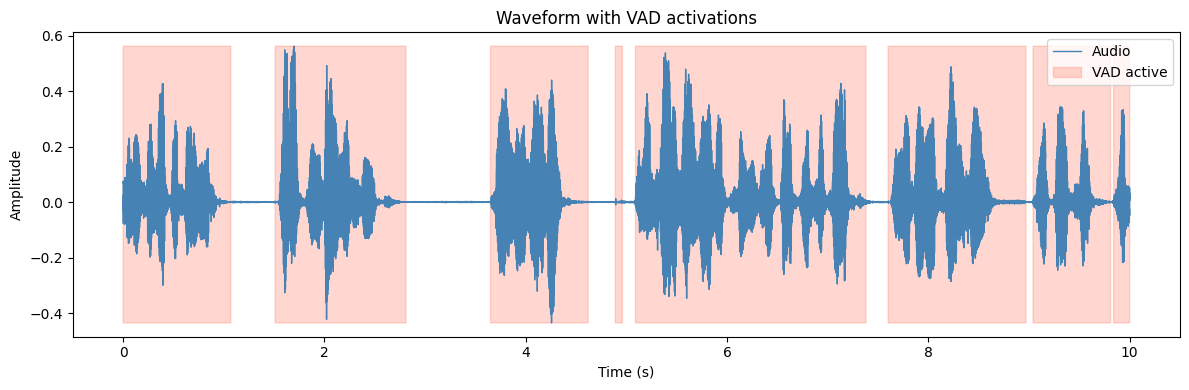

chunk duration: 10.000s


In [393]:
chunk_size = int(10 * 32_000) # 10s chunk
ten_ms = 10 / 1000
bytes_per_ten_ms = int(ten_ms * (sr * ch * sw))
frame_samples = int(ten_ms * sr)

for i in range(0, len(data), chunk_size):
	chunk = data[i:i + chunk_size]
	audio = normalize_audio(chunk)

	vad_mask = vad_collector(chunk, bytes_per_ten_ms, vad)

	t = np.arange(audio.shape[0]) / sr

	plt.figure(figsize=(12, 4))
	plt.plot(t, audio, label="Audio", linewidth=1.0, color="steelblue")
	plt.fill_between(
		t,
		audio.min(),
		audio.max(),
		where=vad_mask > 0,
		color="tomato",
		alpha=0.25,
		label="VAD active"
	)
	plt.xlabel("Time (s)")
	plt.ylabel("Amplitude")
	plt.title("Waveform with VAD activations")
	plt.legend(loc="upper right")
	plt.tight_layout()
	plt.show()

	print(f"chunk duration: {audio.shape[0] / sr:.3f}s")
	break

In [ ]:
ten_ms = 10 / 1000
bytes_per_ten_ms = int(ten_ms * (sr * ch * sw))
frame_samples = int(ten_ms * sr)

chunk_size = 4096

for i in range(0, len(data), chunk_size):
	chunk = data[i:i + chunk_size]
	audio = normalize_audio(chunk)

	vad_mask = vad_collector(chunk, bytes_per_ten_ms, vad)

	print(f"chunk duration: {audio.shape[0] / sr:.3f}s")
	break

[0.06951904 0.05117798 0.05148315 ... 0.16516113 0.09014893 0.23016357]
[1. 1. 1. ... 1. 1. 1.]
chunk duration: 0.128s


In [ ]:
f = True

In [377]:
s = []

In [381]:
print(s)
s.extend([f] * 3)
print(s)

[True, True, True, True, True, True]
[True, True, True, True, True, True, True, True, True]


[transformers] It is strongly recommended to pass the `sampling_rate` argument to `WhisperFeatureExtractor()`. Failing to do so can result in silent errors that might be hard to debug.


(1, 128, 12)


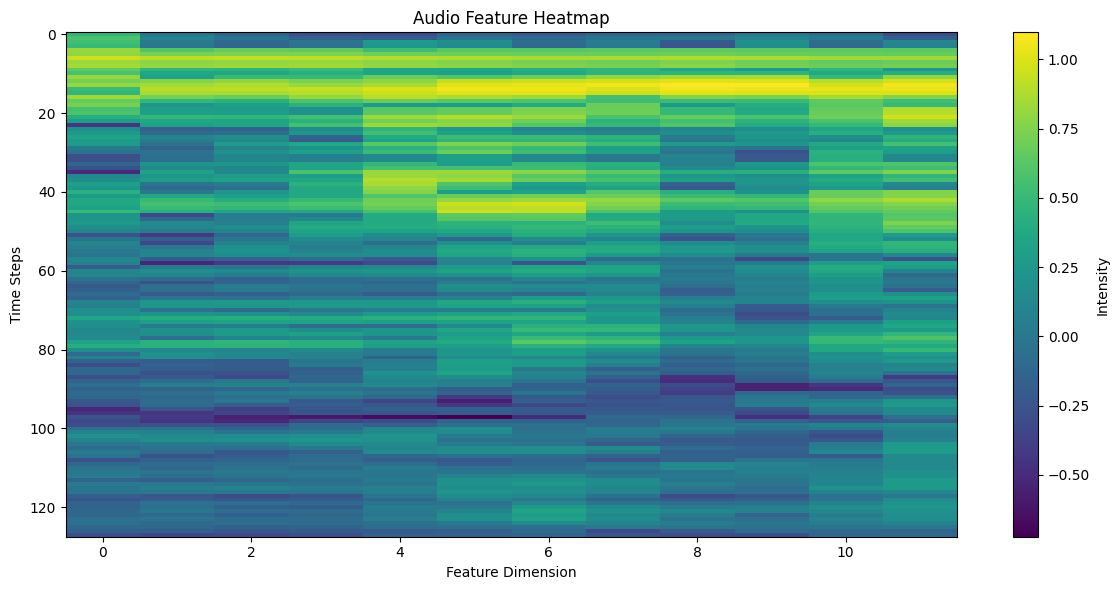

In [163]:
fe = WhisperFeatureExtractor.from_pretrained(
	"./models/whisper-large-v3-turbo",
	chunk_length=1,
	# feature_size=80
)

_x = fe(
	audio,
	padding="do_not_pad"
).input_features

print(_x.shape)

_mel_spectrogram = _x[0]
plt.figure(figsize=(12, 6))
plt.imshow(_mel_spectrogram, aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Feature Dimension')
plt.ylabel('Time Steps')
plt.title('Audio Feature Heatmap')
plt.tight_layout()
plt.show()

In [217]:
sample_rate = 16000
frame_duration = 10  # ms
frame = b'\x00\x00' * int(sample_rate * frame_duration / 1000)
print(len(frame))
# print(f'Contains speech: {vad.is_speech(frame, sample_rate)}')

320


In [298]:
# frame_samples

1 * (sr * sw * ch)


32000